# Longevidade de casamentos

## 2. Modelagem, validação e insights

Este notebook compara KNN, Árvore de Decisão, Random Forest e Naive Bayes. A escolha é feita na validação cruzada; o conjunto de teste é usado uma única vez ao final.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style='whitegrid', palette='deep')
project_dir = Path.cwd()
if not (project_dir / 'marriage_longevity_master.csv').exists():
    project_dir = project_dir.parent
raw = pd.read_csv(project_dir / 'marriage_longevity_master.csv')
eligible = raw.loc[raw['divorced'].eq(1) | raw['years_married'].ge(10)].copy()
eligible['lasted_10_years'] = eligible['years_married'].ge(10).astype(int)

## Partição e pré-processamento

A separação estratificada preserva a proporção das classes. A normalização é essencial para KNN e também mantém uma entrada comparável para Naive Bayes. Para variáveis categóricas, usa-se codificação one-hot com tratamento seguro de categorias novas.

In [2]:
features = [
    'marriage_number', 'age_at_marriage', 'age_gap_years', 'education_level',
    'household_income_usd', 'financial_stress', 'both_employed', 'cohabited_before',
    'premarital_counseling', 'child_before_marriage', 'n_children',
    'religious_attendance', 'criticism', 'contempt', 'defensiveness', 'stonewalling',
    'repair_attempt_success', 'positive_negative_ratio', 'conflict_frequency_weekly',
    'shared_activities_weekly'
]
X = eligible[features]
y = eligible['lasted_10_years']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(exclude='object').columns.tolist()
preprocessor = ColumnTransformer([
    ('numerical', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('categorical', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
])
pd.DataFrame({'conjunto': ['Treino', 'Teste'], 'linhas': [len(X_train), len(X_test)], 'proporção_durou_10_anos': [y_train.mean(), y_test.mean()]}).style.format({'proporção_durou_10_anos': '{:.1%}'})

,conjunto,linhas,proporção_durou_10_anos
0,Treino,27625,55.8%
1,Teste,6907,55.8%


## Comparação justa de modelos

A validação cruzada estratificada de 5 dobras usa somente a amostra de treino. A AUC-ROC é o critério principal porque avalia a capacidade de ordenar os casos sem depender de um único limiar; F1 e acurácia total complementam a avaliação após classificar.

In [3]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=15, weights='distance'),
    'Árvore de decisão': DecisionTreeClassifier(max_depth=6, min_samples_leaf=30, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=10, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
    'Naive Bayes': GaussianNB()
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'AUC-ROC': 'roc_auc', 'Acurácia': 'accuracy', 'F1': 'f1'}
results = []
for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    scores = cross_validate(pipeline, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1)
    results.append({
        'modelo': name,
        'AUC-ROC média': scores['test_AUC-ROC'].mean(),
        'AUC-ROC desvio': scores['test_AUC-ROC'].std(),
        'Acurácia': scores['test_Acurácia'].mean(),
        'F1': scores['test_F1'].mean()
    })
comparison = pd.DataFrame(results).sort_values('AUC-ROC média', ascending=False).reset_index(drop=True)
comparison.style.format({column: '{:.3f}' for column in comparison.columns if column != 'modelo'}).background_gradient(subset=['AUC-ROC média'], cmap='YlGn')

,modelo,AUC-ROC média,AUC-ROC desvio,Acurácia,F1
0,Random Forest,0.734,0.007,0.669,0.686
1,Naive Bayes,0.718,0.006,0.664,0.686
2,KNN,0.688,0.007,0.635,0.685
3,Árvore de decisão,0.676,0.006,0.624,0.627


O **Random Forest** é selecionado por apresentar a maior AUC-ROC média. Além do ganho de desempenho, ele captura relações não lineares e interações entre fatores, sem perder a possibilidade de interpretar a importância das variáveis.

Modelo selecionado: Random Forest
AUC-ROC no teste: 0.735
                   precision    recall  f1-score   support

Não durou 10 anos      0.614     0.698     0.653      3055
    Durou 10 anos      0.731     0.652     0.689      3852

         accuracy                          0.672      6907
        macro avg      0.673     0.675     0.671      6907
     weighted avg      0.679     0.672     0.673      6907



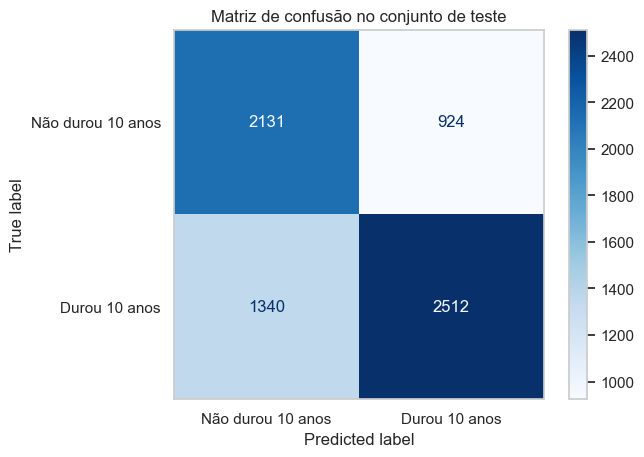

In [4]:
best_name = comparison.loc[0, 'modelo']
final_pipeline = Pipeline([('preprocessor', preprocessor), ('model', models[best_name])])
final_pipeline.fit(X_train, y_train)
test_predictions = final_pipeline.predict(X_test)
test_probabilities = final_pipeline.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probabilities)
print(f'Modelo selecionado: {best_name}')
print(f'AUC-ROC no teste: {test_auc:.3f}')
print(classification_report(y_test, test_predictions, target_names=['Não durou 10 anos', 'Durou 10 anos'], digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, display_labels=['Não durou 10 anos', 'Durou 10 anos'], cmap='Blues')
plt.title('Matriz de confusão no conjunto de teste')
plt.grid(False)
plt.show()

## Insights do modelo

As importâncias abaixo mostram quais variáveis mais ajudaram a separar os dois grupos. Elas descrevem associação preditiva no conjunto estudado, não causalidade.

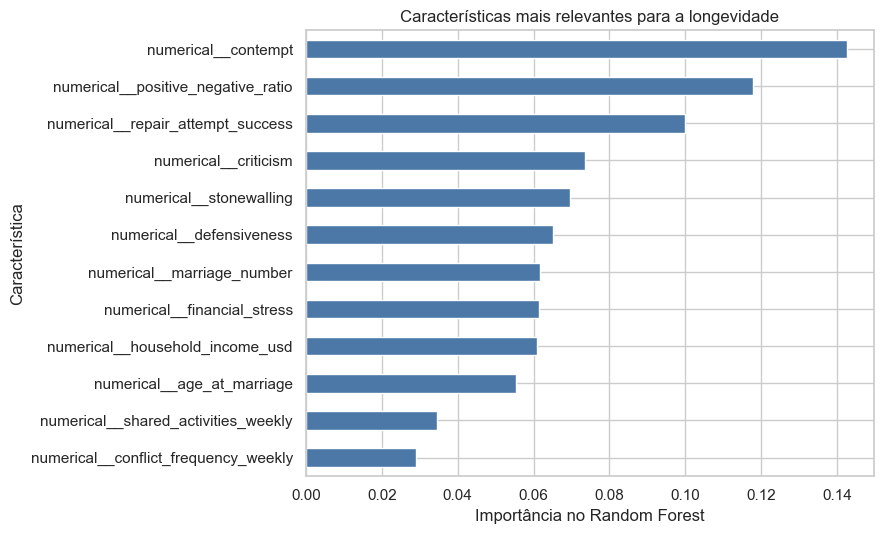

,importância
numerical__contempt,0.142639
numerical__positive_negative_ratio,0.117828
numerical__repair_attempt_success,0.099857
numerical__criticism,0.073601
numerical__stonewalling,0.069719
numerical__defensiveness,0.065141
numerical__marriage_number,0.061693
numerical__financial_stress,0.061487
numerical__household_income_usd,0.060824
numerical__age_at_marriage,0.055375


In [5]:
if best_name == 'Random Forest':
    transformed_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
    importance = pd.Series(final_pipeline.named_steps['model'].feature_importances_, index=transformed_names)
    importance = importance.sort_values(ascending=False).head(12).sort_values()
    plt.figure(figsize=(9, 5.5))
    importance.plot.barh(color='#4C78A8')
    plt.xlabel('Importância no Random Forest')
    plt.ylabel('Característica')
    plt.title('Características mais relevantes para a longevidade')
    plt.tight_layout()
    plt.show()
    display(importance.sort_values(ascending=False).to_frame('importância'))

## Conclusão e limites

- O modelo escolhido é o **Random Forest**, pois venceu a comparação por AUC-ROC em validação cruzada e foi confirmado em um conjunto de teste isolado.
- Indicadores de interação do casal, especialmente desprezo, proporção de interações positivas/negativas e sucesso em reparações, tendem a concentrar a maior informação preditiva.
- O modelo é uma ferramenta de apoio, não um diagnóstico. Importância de variável não prova causa e resultados devem ser avaliados quanto a vieses de coleta e representatividade.
- Para uso real, seria necessário garantir que todos os preditores sejam medidos antes da decisão e monitorar desempenho e equidade ao longo do tempo.

## Roteiro sugerido para 10 minutos

1. Problema e definição de sucesso (1 min).
2. Dados, exclusão dos censurados e prevenção de vazamento (2 min).
3. Pré-processamento, divisão treino/teste e validação cruzada (2 min).
4. Comparação dos quatro modelos e escolha do Random Forest (2 min).
5. Resultado no teste, matriz de confusão e insights (2 min).
6. Limites e mensagem final (1 min).